## Data Preparation and Cleaning
The raw datasets are loaded and prepared for further spatial analysis. 

In [18]:
#import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import functions 
import pandas as pd
from shapely.geometry import Point
from shapely import wkt
import geopandas as gpd
import mapclassify
#load datasets
raw_zwn = pd.read_csv("../data/raw/zwn_meldungen.csv")
raw_popsize = pd.read_csv("../data/raw/populationsize_zh.csv")
raw_quartiere = pd.read_csv("../data/raw/quartiere_zürich.csv")


#select needed columns
processed_zwn = raw_zwn[["service_name","requested_datetime","e","n","status","updated_datetime"]]
processed_quartiere = raw_quartiere[["qname","geometry"]]
pop_size = raw_popsize[["QuarLang","AnzBestWir","StichtagDatJahr"]]


#define new column names
new_names = {
"service_name":"category",
"e":"East",
"n":"North",
"requested_datetime":"report_time",
"updated_datetime":"resolved_time",
    }
processed_zwn= processed_zwn.rename(columns=new_names)

new_names1 = {
"qname":"Quartier",
    "geometry": "Geometry"
}
processed_quartiere= processed_quartiere.rename(columns=new_names1)

new_names_2 = {
"QuarLang":"Quartier",
"AnzBestWir":"PopSize",
}
pop_size= pop_size.rename(columns=new_names_2)

# Check missing values

#-------------------------------------------------------------------------------------------------------------------------
# Prepare processed_zwn dataset
#-------------------------------------------------------------------------------------------------------------------------

# convert datatype of "report_time" and "resolved_time" to datetime64
processed_zwn["report_time"] = pd.to_datetime(processed_zwn["report_time"], format ="%Y-%m-%dT%H:%M:%S")
processed_zwn["resolved_time"] = pd.to_datetime(processed_zwn["resolved_time"], format ="%Y-%m-%dT%H:%M:%S")

# create GeoDataFrame using the East and North coordinates as point geometry
processed_zwn = gpd.GeoDataFrame(processed_zwn,geometry=gpd.points_from_xy(processed_zwn["East"], processed_zwn["North"])
)
# select useful columns (without East and North)
#processed_zwn= processed_zwn[["category","report_time","geometry","status","resolved_time"]]

#define CRS (CH1903+ / LV95)
processed_zwn = processed_zwn.set_crs(epsg=2056)

#-------------------------------------------------------------------------------------------------------------------------
# Prepare processed_quartiere dataset
#-------------------------------------------------------------------------------------------------------------------------

# Convert geometry column from string format into geometry objects
processed_quartiere["Geometry"] = processed_quartiere["Geometry"].apply(wkt.loads)

#define "Geometry" column as spatial geometry in a GeoDataFrame
processed_quartiere = gpd.GeoDataFrame(
    processed_quartiere,
    geometry="Geometry")

#define missing CRS (CH1903+ / LV95)
processed_quartiere = processed_quartiere.set_crs(epsg=2056)


#-------------------------------------------------------------------------------------------------------------------------
# Prepare pop_size dataset
#-------------------------------------------------------------------------------------------------------------------------

# choose year 2025
pop_size= popsize[raw_popsize["StichtagDatJahr"]	== 2025]

## Question 1a: What categories of problems are most frequently reported in each neighbourhood?

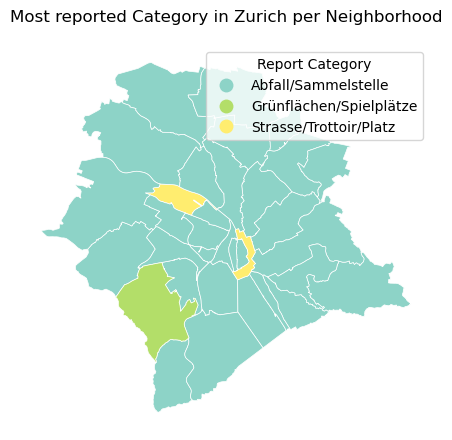

In [30]:
#----------------------------------------------------------------------------------------------------
#Spatial join: assign each report to a neighbourhood
#----------------------------------------------------------------------------------------------------
zwn_with_quartiere = gpd.sjoin(processed_zwn,processed_quartiere, how="left", predicate ="within")

#---------------------------------------------------------------------------------------------------
#Data Analysis: choose category with the most reported problems per neighbourhood
#---------------------------------------------------------------------------------------------------
count = zwn_with_quartiere.groupby(["Quartier","category"]).size().reset_index(name="count")
result = count.sort_values(["Quartier", "count"], ascending=[True, False]).drop_duplicates("Quartier")
map_df = processed_quartiere.merge(result, on="Quartier",how="left")

#---------------------------------------------------------------------------------------------------------
# Create Map
#---------------------------------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10,5)) # creates empty figure 

map_df.plot(
    column="category", 
    categorical=True,
    edgecolor = "white",
    legend=True,
    linewidth = 0.5,
    cmap = "Set3",
    ax=ax,
    legend_kwds={ "title": "Report Category" })

ax.axis("off")
ax.set_title("Most reported Category in Zurich per Neighborhood")

plt.show()


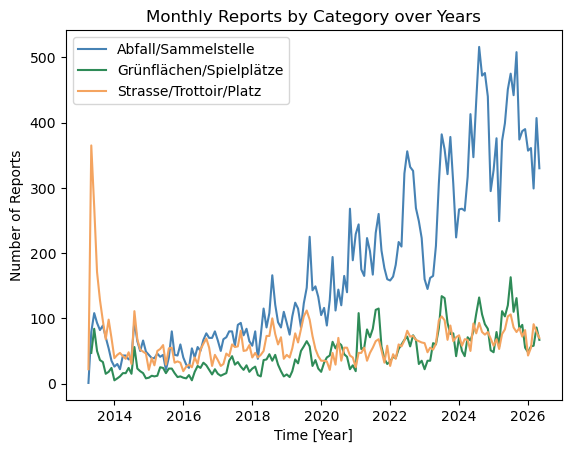

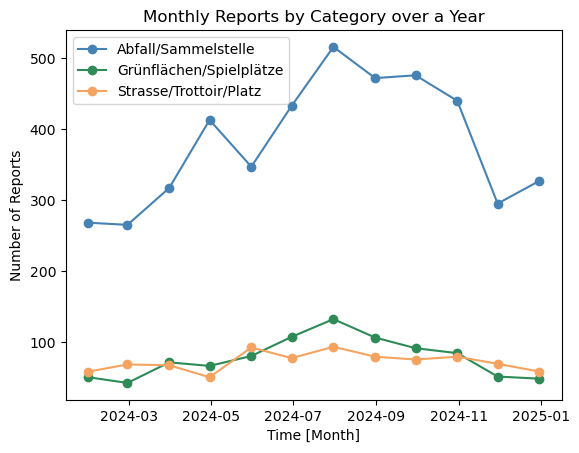

In [19]:
# Question 3: "How do report volumes change overtime in Zurich per category ?"
import functions
#perform spatial join
zwn_with_quartiere = gpd.sjoin(processed_zwn,processed_quartiere, how="left", predicate ="intersects")
#Check NaN values in spatial join: 8 NaN values out of 72'411 reports
zwn_with_quartiere["Quartier"].isna().sum()
zwn_with_quartiere[zwn_with_quartiere["Quartier"].isna()]


functions.plot_category_over_years(zwn_with_quartiere,["Abfall/Sammelstelle","Grünflächen/Spielplätze","Strasse/Trottoir/Platz",])
functions.plot_category_over_a_year(zwn_with_quartiere,["Abfall/Sammelstelle","Grünflächen/Spielplätze","Strasse/Trottoir/Platz",],2024)



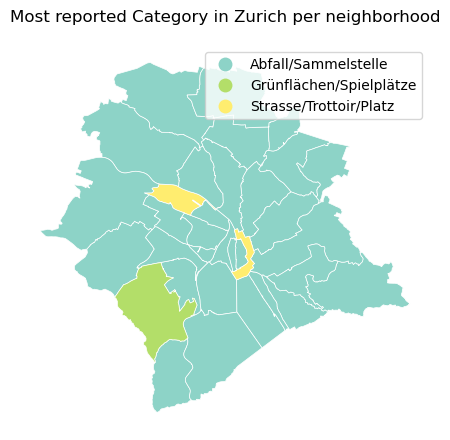

In [20]:
# Question 1: "Welche Problemkategorien werden im jeweiligen statistischen Qaurtier am häufigsten gemeldet?

#perform spatial join
zwn_with_quartiere = gpd.sjoin(processed_zwn,processed_quartiere, how="left", predicate ="within")




#count how many times a specific category in a specific quartier is reported
#reset_index wird verwendet, da Output sind Index(also Quartiernamen ist der Index) ist und man will wieder normale Spalten
#name="count" ist der Name der Spalte, sonst wäre er 0

count = zwn_with_quartiere.groupby(["Quartier","category"]).size().reset_index(name="count")
result = count.sort_values(["Quartier", "count"], ascending=[True, False]).drop_duplicates("Quartier")


#plot
import matplotlib.pyplot as plt
#verbindet beide Tabellen über Spalte Quartier
map_df = processed_quartiere.merge(result, on="Quartier",how="left") #left-->behalte alle Quartiere auch wenn kein Ergebnis existiert

fig, ax = plt.subplots(figsize=(10,5)) # creates empty figure "Graffiti": "red",

map_df.plot(
    column="category", #each Quartier gets a color based on its category
    categorical=True, # treat values as categories and not numbers
    edgecolor = "white",
    legend=True,
    linewidth = 0.5,
    cmap = "Set3",
    ax=ax #draw the axes on the axes we creaed
)
ax.axis("off")
ax.set_title("Most reported Category in Zurich per neighborhood")

plt.show()

#fig, ax = plt.subplots(figsize=(10,5))
#processed_quartiere.plot(ax=ax)
#zwn_with_quartiere.plot(ax=ax,color ="lightgrey")

#plt.show()



# Check NaN values in spatial join: 8 NaN values out of 72'411 reports
#zwn_with_quartiere["Quartier"].isna().sum()
#zwn_with_quartiere[zwn_with_quartiere["Quartier"].isna()]
#zwn_with_quartiere["Quartier"].notna().sum()

#ergänzend Frage1 Abfallmeldungen pro Einwohner pro Quartier, um herauszufinden wo das Abfallproblem das Grösste Problem ist



Question 2

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


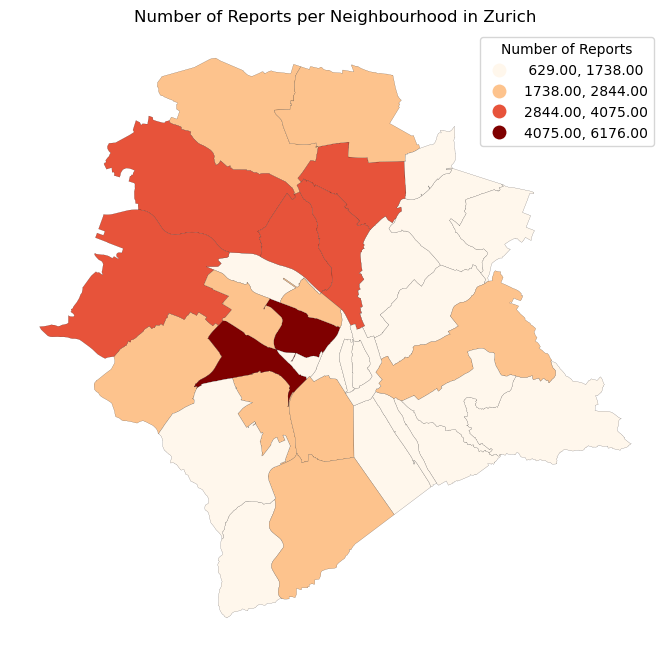

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Text(0, 0.5, 'Frequency')

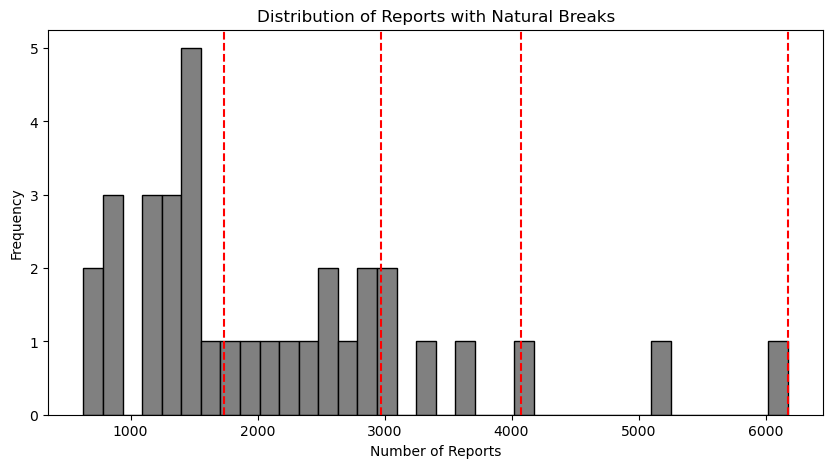

In [21]:
# Question 2: "Which neighbourhood receives the highest number of reports

#perform spatial join
zwn_with_quartiere = gpd.sjoin(processed_zwn,processed_quartiere, how="left", predicate ="within")

#count how many times a report has been submittet in a specific quartier 
count = zwn_with_quartiere.groupby(["Quartier"]).size().reset_index(name="count")



#plot
import matplotlib.pyplot as plt
#verbindet beide Tabellen über Spalte Quartier
map_df = processed_quartiere.merge(count, on="Quartier",how="left") #left-->behalte alle Quartiere auch wenn kein Ergebnis existiert
fig, ax = plt.subplots(figsize=(16,8)) # creates empty figure 


#plot
map_df.plot(
    column="count",
    scheme = "naturalbreaks",
    k = 4,
    edgecolor = "black",
    legend=True,
    linewidth = 0.1,
    cmap="OrRd",
    ax=ax, #draw the axes on the axes we creaed
      legend_kwds={
        "title": "Number of Reports",
      }
)
ax.set_title("Number of Reports per Neighbourhood in Zurich")

ax.axis("off")



plt.show()
#plt.show()


#fig, ax = plt.subplots(figsize=(10,5))
#processed_quartiere.plot(ax=ax)
#zwn_with_quartiere.plot(ax=ax,color ="lightgrey")

plt.show()

#histogram

import mapclassify

classifier = mapclassify.NaturalBreaks(count["count"],k=4)
breaks = classifier.bins

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(count["count"], bins=36, color= "grey",edgecolor="black")

for i in breaks:
    plt.axvline(i, color="red", linestyle="--")

plt.title("Distribution of Reports with Natural Breaks")
plt.xlabel("Number of Reports")
plt.ylabel("Frequency")




Question 3: How do report volumes change overtime per category in Zurich ?

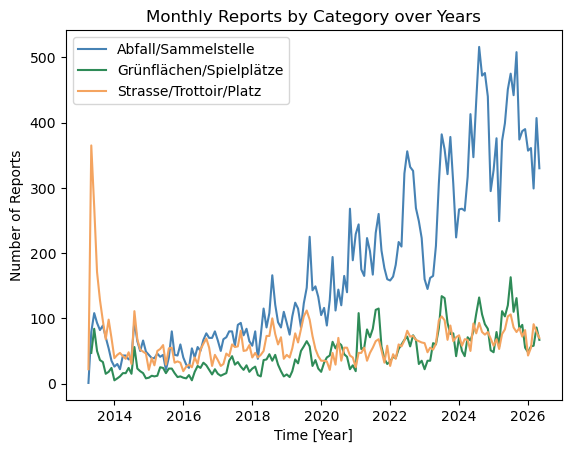

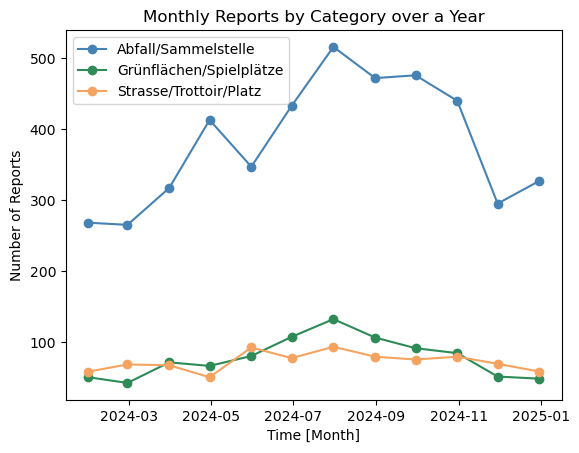

In [22]:
# Question 3: "How do report volumes change overtime in Zurich per category ?"
import functions
#perform spatial join
zwn_with_quartiere = gpd.sjoin(processed_zwn,processed_quartiere, how="left", predicate ="within")

functions.plot_category_over_years(zwn_with_quartiere,["Abfall/Sammelstelle","Grünflächen/Spielplätze","Strasse/Trottoir/Platz",])
functions.plot_category_over_a_year(zwn_with_quartiere,["Abfall/Sammelstelle","Grünflächen/Spielplätze","Strasse/Trottoir/Platz",],2024)


Question 4: “How does the processing time vary across neighbourhoods by category in Zurich?”

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


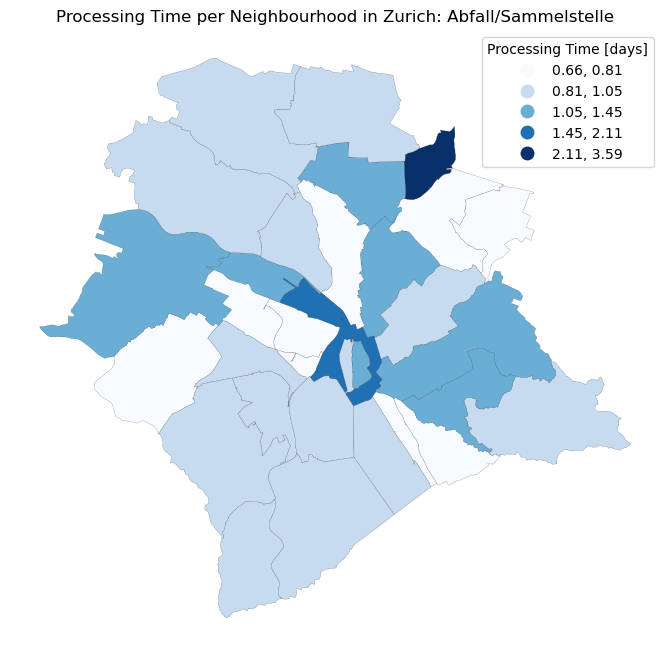

In [23]:
# Question 4: "Wie unterscheidet sich die Bearbeitungszeit der Quartiere pro Kategorie? "
#perform spatial join
zwn_with_quartiere = gpd.sjoin(processed_zwn,processed_quartiere, how="left", predicate ="within")
zwn_filtred= zwn_with_quartiere[zwn_with_quartiere["status"] =="fixed - council"]

mean = functions.calculate_mean_processing_time(zwn_filtred,["Abfall/Sammelstelle"])
#plot
#import matplotlib.pyplot as plt
#verbindet beide Tabellen über Spalte Quartier
map_df = processed_quartiere.merge(mean, on="Quartier",how="left") #left-->behalte alle Quartiere auch wenn kein Ergebnis existiert

fig, ax = plt.subplots(figsize=(16,8)) # creates empty figure 
#plot
map_df.plot(column="processing_time_float",
            scheme = "naturalbreaks",
            edgecolor = "black",
            legend=True,
            linewidth = 0.1,
            cmap="Blues",
            ax=ax, #draw the axes on the axes we creaed
            legend_kwds={
                "title": "Processing Time [days]",})
ax.set_title("Processing Time per Neighbourhood in Zurich: Abfall/Sammelstelle")
ax.axis("off")
plt.show()